# Notebook 12: Performance Improvements Over Baseline

Milestone 1 baseline (Logistic Regression on TF-IDF + dialogue features): macro F1 = 0.591.

Trying two methods to push past the baseline:
1. SMOTE oversampling: handle class imbalance by generating synthetic minority class examples
2. Character n-grams: add char-level TF-IDF features alongside word n-grams

Applied to the main section classification task.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from imblearn.over_sampling import SMOTE

train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')

section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}
train_df['section_group'] = train_df['section_header'].map(section_mapping)
y = train_df['section_group'].values

def extract_dialogue_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

X_dialogue = extract_dialogue_features(train_df)

print(f"Samples: {len(train_df)}")
print(f"Class distribution:")
print(pd.Series(y).value_counts().to_string())

Samples: 1201
Class distribution:
History                  821
Medications/Allergies    122
Exam/Review               83
Chief Complaint           77
Assessment/Diagnosis      53
Plan/Disposition          45


## Experiment 1: Baseline (Milestone 1 setup)

Word n-grams (1,2) plus dialogue features, LogReg with class_weight='balanced'. Should reproduce F1 around 0.59.

In [2]:
def evaluate_cv(X, y, model, cv=5, tag=''):
    """5-fold CV, return mean macro F1 + per-class F1."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    overall_f1 = []
    per_class_f1 = {cls: [] for cls in np.unique(y)}

    for train_idx, val_idx in skf.split(np.zeros(len(y)), y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        m = model.__class__(**model.get_params())
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_val)
        overall_f1.append(f1_score(y_val, y_pred, average='macro'))
        for cls in np.unique(y):
            per_class_f1[cls].append(f1_score(y_val, y_pred, labels=[cls], average='macro'))

    return {
        'tag': tag,
        'macro_f1': np.mean(overall_f1),
        'macro_f1_std': np.std(overall_f1),
        'per_class': {cls: np.mean(scores) for cls, scores in per_class_f1.items()},
    }

# Baseline: word n-grams + dialogue features
tfidf_word = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2), min_df=2, max_df=0.95)
X_word = tfidf_word.fit_transform(train_df['dialogue'])
X_baseline = hstack([X_word, X_dialogue.values])
scaler = MaxAbsScaler()
X_baseline_scaled = scaler.fit_transform(X_baseline)

baseline_model = LogisticRegression(C=0.1, solver='lbfgs', class_weight='balanced', random_state=42, max_iter=2000)
baseline_result = evaluate_cv(X_baseline_scaled, y, baseline_model, tag='Baseline (word n-grams)')

print(f"Baseline: F1 = {baseline_result['macro_f1']:.3f} (+/- {baseline_result['macro_f1_std']:.3f})")
print(f"Features: {X_baseline_scaled.shape[1]}")

Baseline: F1 = 0.579 (+/- 0.040)
Features: 505


## Experiment 2: Add Character N-Grams

Adding char-level TF-IDF (3 to 5 grams) alongside word n-grams. The idea is that character grams can pick up on word morphology and handle abbreviations or typos that show up in medical text.

In [3]:
tfidf_char = TfidfVectorizer(max_features=500, analyzer='char_wb', ngram_range=(3,5), min_df=2, max_df=0.95)
X_char = tfidf_char.fit_transform(train_df['dialogue'])

# Combine word + char + dialogue features
X_combined = hstack([X_word, X_char, X_dialogue.values])
scaler_c = MaxAbsScaler()
X_combined_scaled = scaler_c.fit_transform(X_combined)

char_result = evaluate_cv(X_combined_scaled, y, baseline_model, tag='Word + Char n-grams')
print(f"Word + Char: F1 = {char_result['macro_f1']:.3f} (+/- {char_result['macro_f1_std']:.3f})")
print(f"Features: {X_combined_scaled.shape[1]}")
print(f"Improvement over baseline: {char_result['macro_f1'] - baseline_result['macro_f1']:+.3f}")

Word + Char: F1 = 0.597 (+/- 0.034)
Features: 1005
Improvement over baseline: +0.018


## Experiment 3: SMOTE Oversampling

Instead of `class_weight='balanced'`, use SMOTE to synthesize minority class examples and directly balance the training data.

Applied inside each CV fold (applying it before splitting would leak).

In [4]:
def evaluate_cv_with_smote(X, y, model, cv=5, tag=''):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    overall_f1 = []
    per_class_f1 = {cls: [] for cls in np.unique(y)}

    for train_idx, val_idx in skf.split(np.zeros(len(y)), y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Apply SMOTE only to training fold
        smote = SMOTE(random_state=42, k_neighbors=3)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

        m = model.__class__(**model.get_params())
        m.fit(X_tr_res, y_tr_res)
        y_pred = m.predict(X_val)
        overall_f1.append(f1_score(y_val, y_pred, average='macro'))
        for cls in np.unique(y):
            per_class_f1[cls].append(f1_score(y_val, y_pred, labels=[cls], average='macro'))

    return {
        'tag': tag,
        'macro_f1': np.mean(overall_f1),
        'macro_f1_std': np.std(overall_f1),
        'per_class': {cls: np.mean(scores) for cls, scores in per_class_f1.items()},
    }

#SMOTE without class weights (SMOTE balances the classes)
smote_model = LogisticRegression(C=0.1, solver='lbfgs', random_state=42, max_iter=2000)

#on baseline features
smote_baseline = evaluate_cv_with_smote(X_baseline_scaled, y, smote_model, tag='SMOTE + Baseline features')
print(f"SMOTE + Baseline features: F1 = {smote_baseline['macro_f1']:.3f} (+/- {smote_baseline['macro_f1_std']:.3f})")

#on word+char features
smote_char = evaluate_cv_with_smote(X_combined_scaled, y, smote_model, tag='SMOTE + Word+Char features')
print(f"SMOTE + Word+Char features: F1 = {smote_char['macro_f1']:.3f} (+/- {smote_char['macro_f1_std']:.3f})")

SMOTE + Baseline features: F1 = 0.588 (+/- 0.038)


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/joshbuck/Library/Python/

SMOTE + Word+Char features: F1 = 0.615 (+/- 0.043)


## Summary

In [5]:
results = [baseline_result, char_result, smote_baseline, smote_char]

summary = pd.DataFrame([
    {
        'Experiment': r['tag'],
        'Macro F1': r['macro_f1'],
        'Std': r['macro_f1_std'],
        'change from baseline': r['macro_f1'] - baseline_result['macro_f1'],
    }
    for r in results
])
print(summary.round(3).to_string(index=False))

# Per-class F1 across experiments
classes = sorted(results[0]['per_class'].keys())
per_class_df = pd.DataFrame({r['tag']: [r['per_class'][c] for c in classes] for r in results}, index=classes)
print("\nPer-class F1:")
print(per_class_df.round(3).to_string())

                Experiment  Macro F1   Std  change from baseline
   Baseline (word n-grams)     0.579 0.040                 0.000
       Word + Char n-grams     0.597 0.034                 0.018
 SMOTE + Baseline features     0.588 0.038                 0.009
SMOTE + Word+Char features     0.615 0.043                 0.037

Per-class F1:
                       Baseline (word n-grams)  Word + Char n-grams  SMOTE + Baseline features  SMOTE + Word+Char features
Assessment/Diagnosis                     0.335                0.309                      0.281                       0.312
Chief Complaint                          0.465                0.516                      0.486                       0.536
Exam/Review                              0.578                0.633                      0.588                       0.670
History                                  0.869                0.864                      0.895                       0.890
Medications/Allergies                    0.78

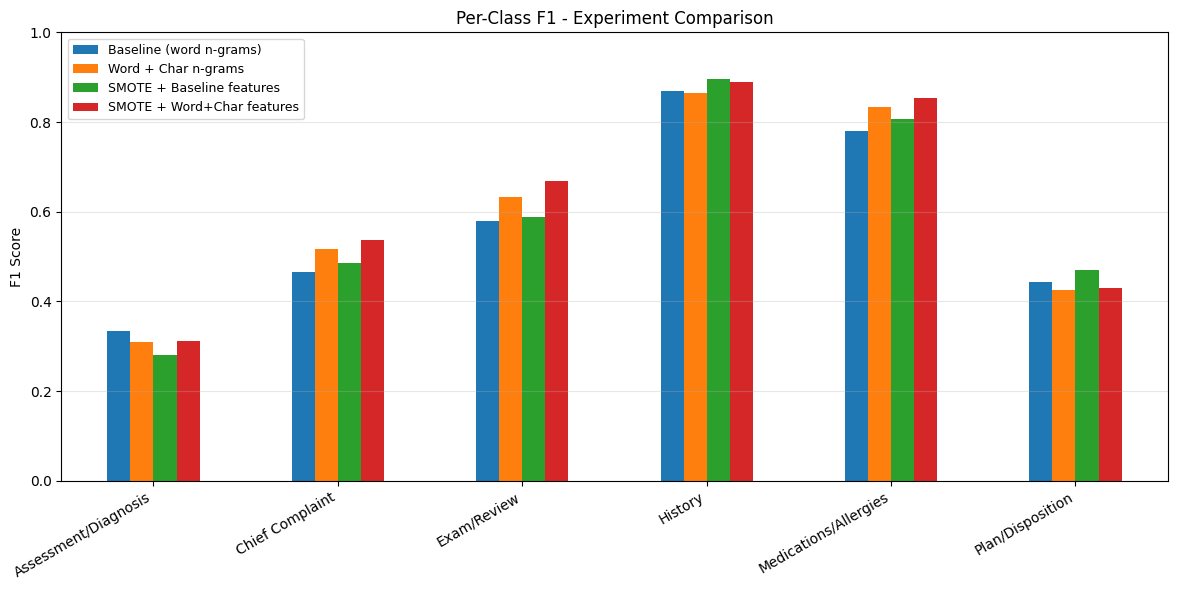

In [6]:
# Visualize per-class F1 across experiments
fig, ax = plt.subplots(figsize=(12, 6))
per_class_df.plot(kind='bar', ax=ax)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 - Experiment Comparison')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()